### Purpose
This notebook compares the baseline model against the hybrid model and measures whether hybrid model improves predictive performance.
<br> --- --- --- <br>
Este notebook compara o modelo baseline com o modelo híbrido e mede se o modelo hibrido melhora o desempenho preditivo.
<br>
📝 Language: Technical documentation is maintained in English to ensure consistency and ease of maintenance. Bilingual support (Portuguese/English) is available exclusively within the notebooks.
<br> --- --- --- <br>
📝 Idioma: A documentação é mantida em inglês para garantir consistência técnica e evitar retrabalho na documentação. Isto aplica-se somente aos notebooks.

##### ⚙️The project follows this logic:
**raw data -> data quality -> feature engineering -> anomaly detection -> baseline model -> hybrid model -> performance benchmarking**

##### ⚙️Execution order
📝01_data_loading.ipynb -> 📝02_data_quality.ipynb -> 📝03_feature_engineering.ipynb -> 📝04_anomaly_detection.ipynb -> 
📝05_BaseLine.ipynb -> 📝06_HybridModel.ipynb -> 📝07_Interpretability_SHAP_Analysis.ipynb -> 📝08_performance_benchmarking.ipynb 


### Main idea
The notebook builds a structured comparison between:
- a baseline LightGBM model trained only on engineered features
- a hybrid LightGBM model trained with anomaly-related signals
<br> --- --- --- <br>
O notebook constrói uma comparação estruturada entre:
- um modelo baseline LightGBM treinado apenas com features engenheiradas
- um modelo híbrido LightGBM treinado com sinais relacionados a anomalias

### Inputs
- 📦`beverage_sales_feature.parquet`
- 📦`anomaly_predictions.parquet`
- 📊baseline trained model
- 📊hybrid trained model

### Main processing steps
1. Load features and anomaly datasets.
2. Convert `Order_Date` to datetime.
3. Create train and test subsets:
   - 2021–2022 for training comparison
   - 2023 for final comparison
4. Prepare feature lists for both approaches.
5. Use `ModelsMetricsReporter` to compare:
   - baseline model
   - hybrid model
6. Generate grouped performance tables, including comparison by anomaly flag.
7. Plot a vertical visual comparison of the models.
<br>
<br> --- --- --- <br>
1. Carregar os datasets de features e anomalias.
2. Converter `Order_Date` para datetime.
3. Criar subconjuntos de treino e teste:
   - 2021–2022 para comparação de treino
   - 2023 para comparação final
4. Preparar as listas de features para as duas abordagens.
5. Usar `ModelsMetricsReporter` para comparar:
   - modelo baseline
   - modelo híbrido
6. Gerar tabelas de desempenho agrupadas, incluindo comparação por flag de anomalia.
7. Plotar uma visualização vertical de comparação entre os modelos.

### Outputs
- 📝Benchmark report table
- 📊Comparison dataframe
- 📈Visualization of model performance
- ✅Evidence of whether the hybrid model performs better on anomalous periods or groups

### Why this notebook matters
This notebook gives business and technical justification for the hybrid architecture.  
It shows whether anomaly signals add measurable value instead of being included only by intuition.
<br> --- --- --- <br>
Este notebook fornece justificativa técnica e de negócio para a arquitetura híbrida.  
Ele mostra se os sinais de anomalia agregam valor mensurável, em vez de serem incluídos apenas por intuição.

### Notes
- The notebook compares models on both train-like and test datasets. For portfolio presentation, highlight the final test comparison as the most reliable result.
- The presence of grouped metrics by anomaly flag is useful because it shows whether the hybrid model is especially helpful in difficult or unusual demand scenarios.
<br> --- --- --- <br>
- O notebook compara os modelos tanto em dados de treino quanto em dados de teste. Para apresentação em portfólio, vale destacar a comparação final no conjunto de teste como o resultado mais confiável.
- A presença de métricas agrupadas por `anomaly_flag` é útil porque mostra se o modelo híbrido ajuda principalmente nos cenários mais difíceis ou incomuns de demanda.


In [2]:
%load_ext autoreload
%autoreload 2

import os
import glob
from pathlib import Path
import sys
import pyarrow
import pandas as pd

PROJECT_ROOT = Path().resolve().parent
sys.path.append(str(PROJECT_ROOT))

from src.config.config import DATA_PROCESSED, DATA_FEATURES, MODELS_BASELINE,MODELS_METRICS,MODELS_PRODUCTION,MODELS_ANOMALYD
from src.repository.parquet_repository import ParquetRepository
from src.models.LightGBMRegressorBaseLine import LightGBMRegressorBaseLine
from src.models.LightGBMRegressorAnomaly import LightGBMRegressorAnomaly
from src.visualization.ModelsMetricsReporter import ModelsMetricsReporter
from src.XAI.LightGBMShapInterpreter import LightGBMShapInterpreter


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
repo = ParquetRepository(DATA_FEATURES)

In [4]:
df_features = repo.load("beverage_sales_feature.parquet")
df_anomalies = repo.load("anomaly_predictions.parquet")

df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\beverage_sales_feature.parquet
[OK] Arquivo carregado: D:\PROJETOS\git_repo\BEVERAGE-SALES\data\features\anomaly_predictions.parquet


In [5]:
print (df_anomalies.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [6]:
df_model_with_anomaly = df_features.merge(
    df_anomalies,
    on=["Order_Date", "Product", "Region"],
    how="left"
)

In [7]:
print (df_anomalies.dtypes)

Order_Date                  datetime64[ns]
Category                            object
Product                             object
Region                              object
quantity_sum                       float64
total_price_sum                    float64
unit_price_mean                    float64
discount_mean                      float64
order_count                        float64
customer_count                     float64
avg_ticket                         float64
day_of_week                          int32
month                                int32
year                                 int32
is_weekend                           int64
quantity_sum_mean_7d               float64
quantity_sum_std_7d                float64
quantity_sum_sum_7d                float64
total_price_sum_mean_7d            float64
total_price_sum_std_7d             float64
total_price_sum_mean_30d           float64
unit_price_mean_mean_7d            float64
discount_mean_mean_14d             float64
quantity_vs

In [8]:
df_features["Order_Date"] = pd.to_datetime(df_features["Order_Date"])

df_train_features = df_features[df_features["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_features = df_features[df_features["Order_Date"].dt.year == 2023].copy()

In [9]:
df_anomalies["Order_Date"] = pd.to_datetime(df_anomalies["Order_Date"])

df_train_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year.isin([2021, 2022])].copy()
df_test_anomaly = df_anomalies[df_anomalies["Order_Date"].dt.year == 2023].copy()

In [10]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d"
]

categorical_features = [
    "Product",
    "Region"
]

baseline_model = LightGBMRegressorBaseLine(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_BASELINE = MODELS_BASELINE / "lightgbm_baseline_model.joblib"
baseline_model.load_model(LOCAL_BASELINE)

In [11]:
target_col = "quantity_sum"

numeric_features = [
    "total_price_sum",
    "unit_price_mean",
    "discount_mean",
    "order_count",
    "customer_count",
    "avg_ticket",
    "day_of_week",
    "month",
    "is_weekend",
    "quantity_sum_mean_7d",
    "quantity_sum_std_7d",
    "quantity_sum_sum_7d",
    "total_price_sum_mean_7d",
    "total_price_sum_std_7d",
    "total_price_sum_mean_30d",
    "unit_price_mean_mean_7d",
    "discount_mean_mean_14d",
    "quantity_vs_mean_7d",
    "total_price_vs_mean_30d",
    "quantity_pct_vs_mean_7d",
    "history_less_than_7d",
    "history_less_than_30d",
    "anomaly_score",
    "anomaly_flag"
]

categorical_features = [
    "Product",
    "Region"
]

hybrid_model = LightGBMRegressorAnomaly(
    target_col=target_col,
    numeric_features=numeric_features,
    categorical_features=categorical_features,
    model_dir=MODELS_BASELINE,
    random_state=3,
    n_splits=3,
    scoring="neg_root_mean_squared_error"
)

LOCAL_HYBRID_MODEL = MODELS_BASELINE / "lightgbm_anomalies_model.joblib"
hybrid_model.load_model(LOCAL_HYBRID_MODEL)

In [12]:
modelreport = ModelsMetricsReporter (df_baseline=df_train_features, df_with_anomaly=df_train_anomaly)

report, df_compare = modelreport.compare_models_by_anomaly_flag(
    baseline_model=baseline_model,
    anomaly_model=hybrid_model,
    target_col="quantity_sum",
    anomaly_flag_col="anomaly_flag",
    id_columns=["Order_Date", "Product", "Region"]
)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


In [13]:
print(report)

   anomaly_flag   count  baseline_mae  anomaly_model_mae  baseline_median_ae  \
0             0  543470      2.690491            2.69468            1.915619   
1             1    5490      6.394622            6.22014            2.635442   

   anomaly_model_median_ae  baseline_rmse  anomaly_model_rmse  \
0                 1.913718       3.969947            3.967023   
1                 2.639001      13.011426           12.314362   

   baseline_max_ae  anomaly_model_max_ae  mae_improvement  rmse_improvement  \
0       158.320738            151.348713        -0.004188          0.002924   
1       123.955175            114.283118         0.174482          0.697065   

   mae_improvement_pct  rmse_improvement_pct  
0             -0.15566              0.073645  
1              2.72857              5.357326  


In [14]:
modelreport = ModelsMetricsReporter (df_baseline=df_test_features, df_with_anomaly=df_test_anomaly)

report, df_compare = modelreport.compare_models_by_anomaly_flag(
    baseline_model=baseline_model,
    anomaly_model=hybrid_model,
    target_col="quantity_sum",
    anomaly_flag_col="anomaly_flag",
    id_columns=["Order_Date", "Product", "Region"]
)

print(report)

d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(
d:\PROJETOS\git_repo\BEVERAGE-SALES\_venv\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but LGBMRegressor was fitted with feature names
  warnings.warn(


   anomaly_flag   count  baseline_mae  anomaly_model_mae  baseline_median_ae  \
0             0  271161      2.774376           2.773018            1.937265   
1             1    2566      3.516084           3.408859            2.223703   

   anomaly_model_median_ae  baseline_rmse  anomaly_model_rmse  \
0                 1.929886       4.284927            4.257696   
1                 2.127980       7.931240            7.522428   

   baseline_max_ae  anomaly_model_max_ae  mae_improvement  rmse_improvement  \
0       186.172581            161.017983         0.001358          0.027231   
1       263.094056            245.972226         0.107224          0.408812   

   mae_improvement_pct  rmse_improvement_pct  
0             0.048951              0.635510  
1             3.049535              5.154454  


In [15]:
def style_metrics_table(df: pd.DataFrame):
    return (
        df.style
        .format({
            "anomaly_flag":"{:.0f}",
            "count":"{:.0f}",
            "baseline_mae":"{:.3f}",
            "anomaly_model_mae":"{:.3f}",
            "baseline_median_ae":"{:.3f}",
            "anomaly_model_median_ae":"{:.3f}",
            "baseline_rmse":"{:.3f}",
            "anomaly_model_rmse":"{:.3f}",
            "baseline_max_ae":"{:.3f}",
            "anomaly_model_max_ae":"{:.3f}",
            "mae_improvement":"{:.3f}",
            "rmse_improvement":"{:.3f}",
            "mae_improvement_pct":"{:.2f}%",
            "rmse_improvement_pct":"{:.2f}%",
        })
        .set_caption("Baseline x Hibrid Model")
        .set_table_styles([
            {"selector": "th", "props": [("background-color", "#FFDAB9"), ("color", "Black")]},
            {"selector": "caption", "props": [("caption-side", "top"), ("font-size", "14px"), ("font-weight", "bold")]}
        ])
        .background_gradient(subset=["mae_improvement", "rmse_improvement", "mae_improvement_pct", "rmse_improvement_pct"], cmap="PuBuGn")
    )

In [16]:
style_metrics_table (report)

,anomaly_flag,count,baseline_mae,anomaly_model_mae,baseline_median_ae,anomaly_model_median_ae,baseline_rmse,anomaly_model_rmse,baseline_max_ae,anomaly_model_max_ae,mae_improvement,rmse_improvement,mae_improvement_pct,rmse_improvement_pct
0,0,271161,2.774,2.773,1.937,1.930,4.285,4.258,186.173,161.018,0.001,0.027,0.05%,0.64%
1,1,2566,3.516,3.409,2.224,2.128,7.931,7.522,263.094,245.972,0.107,0.409,3.05%,5.15%


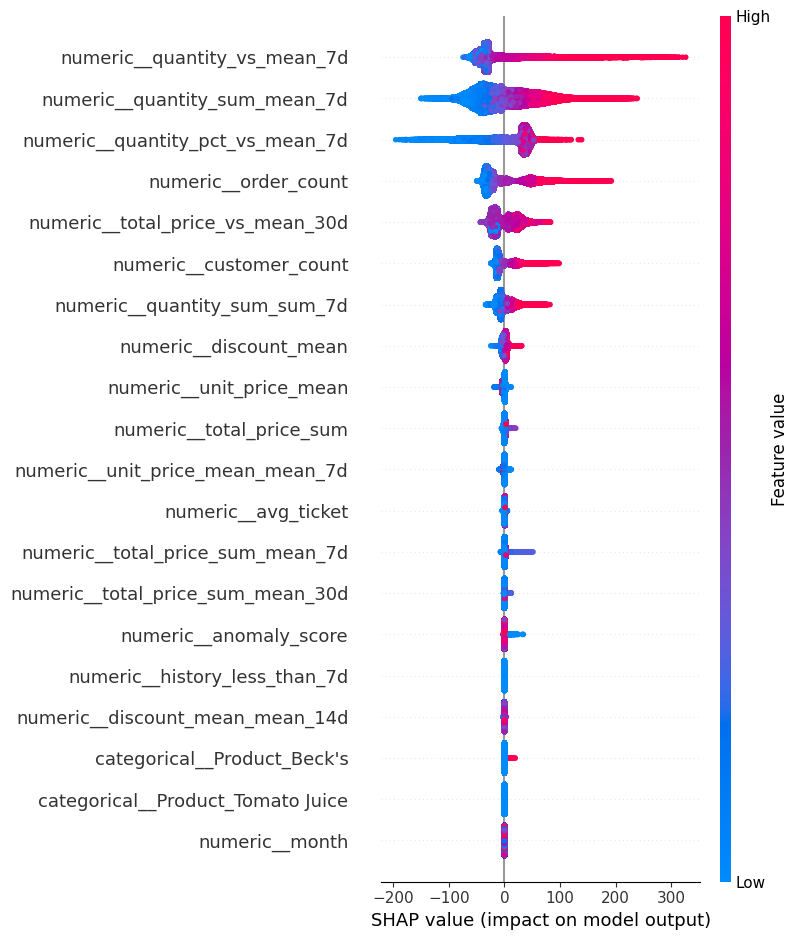

In [17]:
shap_helper = LightGBMShapInterpreter(hybrid_model.best_model)

# gráfico summary
shap_helper.plot_summary(
    df_test_anomaly[hybrid_model.numeric_features + hybrid_model.categorical_features],
    plot_type="dot"
)

In [18]:
importance_df = shap_helper.get_feature_importance(
    df_test_anomaly[hybrid_model.numeric_features + hybrid_model.categorical_features]
)

print(importance_df.head(20))

                              feature  mean_abs_shap
0        numeric__quantity_vs_mean_7d      42.559717
1       numeric__quantity_sum_mean_7d      41.385751
2    numeric__quantity_pct_vs_mean_7d      38.177039
3                numeric__order_count      34.693224
4    numeric__total_price_vs_mean_30d      18.626522
5             numeric__customer_count      15.118905
6        numeric__quantity_sum_sum_7d      10.596499
7              numeric__discount_mean       2.787903
8            numeric__unit_price_mean       1.469957
9            numeric__total_price_sum       1.296059
10   numeric__unit_price_mean_mean_7d       0.787742
11                numeric__avg_ticket       0.631659
12   numeric__total_price_sum_mean_7d       0.617546
13  numeric__total_price_sum_mean_30d       0.198795
14             numeric__anomaly_score       0.111563
15      numeric__history_less_than_7d       0.104011
16    numeric__discount_mean_mean_14d       0.032218
17        categorical__Product_Beck's       0.

In [19]:
df_anomalies = df_test_anomaly[df_test_anomaly["anomaly_flag"] == 1].copy()
X_anomalies = df_anomalies[
    hybrid_model.numeric_features + hybrid_model.categorical_features
].copy()

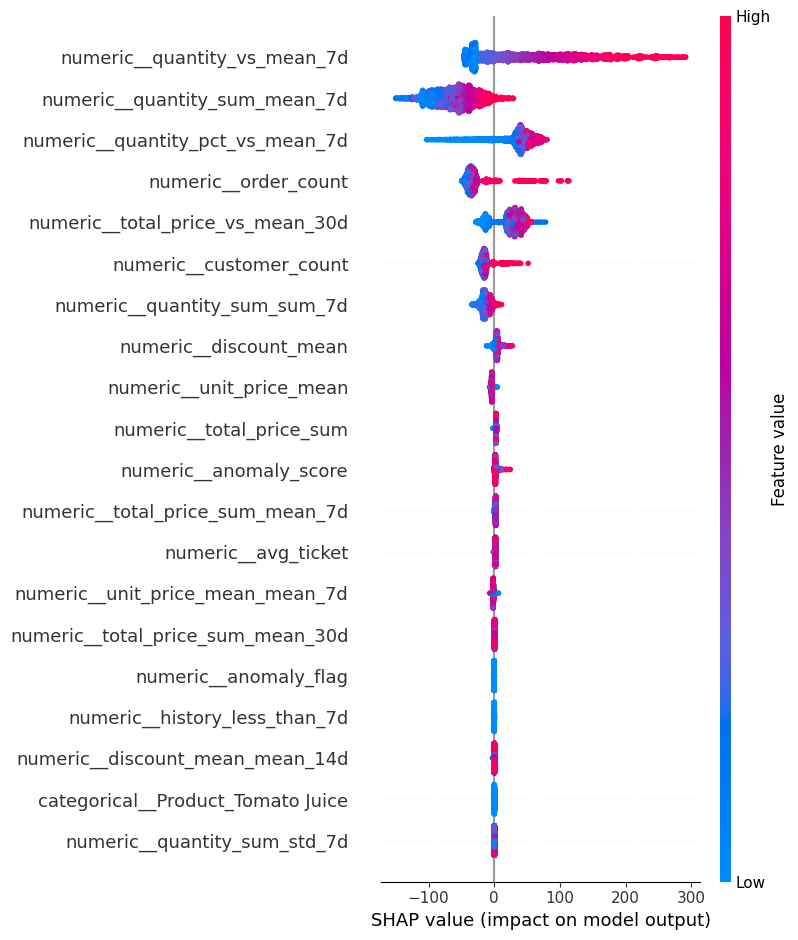

In [20]:
shap_helper.plot_summary(
    df_anomalies[hybrid_model.numeric_features + hybrid_model.categorical_features],
    plot_type="dot"
)

In [21]:
importance_df = shap_helper.get_feature_importance(
    df_anomalies[hybrid_model.numeric_features + hybrid_model.categorical_features]
)

print(importance_df.head(20))

                              feature  mean_abs_shap
0        numeric__quantity_vs_mean_7d      73.117288
1       numeric__quantity_sum_mean_7d      59.671276
2    numeric__quantity_pct_vs_mean_7d      43.165749
3                numeric__order_count      34.752252
4    numeric__total_price_vs_mean_30d      29.322657
5             numeric__customer_count      15.755894
6        numeric__quantity_sum_sum_7d      12.669003
7              numeric__discount_mean       4.175035
8            numeric__unit_price_mean       3.698203
9            numeric__total_price_sum       2.641985
10             numeric__anomaly_score       2.203352
11   numeric__total_price_sum_mean_7d       1.981549
12                numeric__avg_ticket       1.858457
13   numeric__unit_price_mean_mean_7d       1.542865
14  numeric__total_price_sum_mean_30d       0.402258
15              numeric__anomaly_flag       0.138856
16      numeric__history_less_than_7d       0.114185
17    numeric__discount_mean_mean_14d       0.

In [22]:
LOCAL_IF_MODEL = MODELS_ANOMALYD / "isolation_forest_analyzer.joblib"

result = LightGBMRegressorAnomaly.promote_model_to_production(
    lgbm_source_path=LOCAL_HYBRID_MODEL,
    isolation_forest_source_path=LOCAL_IF_MODEL,
    production_dir=MODELS_PRODUCTION,
    model_version="v1",
    target="quantity_sum",
    training_period="2021-2022",
    test_period="2023"
)

print(result)

{'production_dir': 'D:\\PROJETOS\\git_repo\\BEVERAGE-SALES\\models\\production', 'lgbm_model': 'D:\\PROJETOS\\git_repo\\BEVERAGE-SALES\\models\\production\\lgbm_model_v1.joblib', 'isolation_forest': 'D:\\PROJETOS\\git_repo\\BEVERAGE-SALES\\models\\production\\isolation_forest_v1.joblib', 'metadata': 'D:\\PROJETOS\\git_repo\\BEVERAGE-SALES\\models\\production\\model_metadata_v1.json'}
